## General stuff
Guassian:\
$\phi(x) = e^{-\|x\|^2}$

Image function:\
$ f : \mathbb{R}^2 \to \mathbb{R}$

Approximation:\
$ \hat{f}(x) = \sum^n_{i=0}\alpha_i (g_i \triangleright \phi)(y) = \sum^n_{i=0}\alpha_i (\psi(v_i) \triangleright \phi)(y)$

Lie group (dim 6):\
$G = \text{Aff}^+(2)$

Group action on $R^2$:\
For $g \in G, y \in R^2$ then $g \triangleright y = (x, A) \triangleright y := Ay + x$

For $f : \mathbb{R}^2 \to \mathbb{R}$ then $(g \triangleright f)(y) := f(g^{-1} \triangleright y)$ 

Parameter space (dim 6):\
$V = \mathbb{R}^2 \times \text{SO}(2) \times \text{SNM}(2)$

Mapping:\
$\psi : V \to G$\
$\psi(L, X, Y) = (L, \exp(X)\exp(Y))$

For $X = \begin{pmatrix}
0 & b \\
-b & 0
\end{pmatrix}$ then $\exp(X) = \begin{pmatrix}
\cos(b) & \sin(b) \\
-\sin(b) & \cos(b)
\end{pmatrix}$

For
$
Y=\begin{pmatrix}a & b \\ b & c\end{pmatrix},
$
define
$
m=\tfrac{a+c}{2}, \quad 
B = Y - mI = \begin{pmatrix}\tfrac{a-c}{2} & b \\[4pt] b & -\tfrac{a-c}{2}\end{pmatrix}, \quad 
s=\sqrt{b^{2}+\left(\tfrac{a-c}{2}\right)^{2}}.
$

Then
$
\exp(Y) \;=\; e^{\,m}\!\left( \cosh(s)\,I + \frac{\sinh(s)}{s}\,B \right).
$

Loss:\
$\mathcal{L} = \|f-\hat{f}\|_{L^2}$

In [14]:
import torch
import numpy as np
import math
from pytorch_msssim import SSIM

In [15]:
# Mapping from parametric space to lie group

# Map exp of the theta of a 2x2 anti symmetric matrix to explicit
def exp_SO(theta: torch.Tensor) -> torch.Tensor:
    return torch.stack([torch.stack([torch.cos(theta), -torch.sin(theta)]),
                         torch.stack([torch.sin(theta), torch.cos(theta)])]).permute(2, 0, 1)

# Map exp of 2x2 symmetric matrix to explicit
def exp_SNM(a: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
    m = torch.stack([
        torch.stack([torch.exp(a), torch.zeros_like(c)]),
        torch.stack([torch.zeros_like(a), torch.exp(c)])
    ]).permute(2, 0, 1)

    return m




In [16]:
def f_hat(
    color_zeroth: torch.Tensor,
    color_first: torch.Tensor,
    color_second: torch.Tensor,
    scale_shear: torch.Tensor,
    rotation: torch.Tensor,
    translation: torch.Tensor,
    width: int,
    height: int
) -> torch.Tensor:
    """
    Calculate f_hat with w for the grid width to height
    """

    x1 = translation[0]
    x2 = translation[1]

    Y = exp_SNM(scale_shear[0], scale_shear[1])

    A = exp_SO(rotation) @ Y
    x = torch.stack([x1, x2]).permute(1, 0)
    sampling_grid = torch.nn.functional.affine_grid(
        torch.cat([torch.linalg.inv(A), (torch.linalg.inv(A) @ (x*-1).unsqueeze(-1))], dim=-1), 
        torch.Size((A.size()[0], 1, height, width)))
    zeroth_gaussian_values = torch.exp(-1 * (sampling_grid[:,:,:,1]**2 + sampling_grid[:,:,:,0]**2))
    zeroth_image = torch.einsum('gjk,gd->gdjk', zeroth_gaussian_values, color_zeroth.permute(1, 0)).sum(dim=0)

    first_gaussian_values =  -2 * (sampling_grid[:, :,:, 0]/0.7) * torch.exp(-1 * ((sampling_grid[:,:,:,0]/0.7)**2 + sampling_grid[:,:,:,1]**2))
    first_image = torch.einsum('gjk,gd->gdjk', first_gaussian_values, color_first.permute(1, 0)).sum(dim=0)

    second_gaussian_values = (4 * (sampling_grid[:, :,:, 0]/0.5)**2 - 2) * torch.exp(-1 * ((sampling_grid[:,:,:,0]/0.5)**2 + sampling_grid[:,:,:,1]**2))
    second_image = torch.einsum('gjk,gd->gdjk', second_gaussian_values, color_second.permute(1, 0)).sum(dim=0)

    # print(zeroth_gaussian_values.shape, color_zeroth.abs().shape)
    return zeroth_image + first_image + second_image


In [17]:

torch.autograd.set_detect_anomaly(False)

device = torch.device("cuda:0")

def train(learning_rate: float, iterations: int, guassians: int, target: torch.Tensor, normalize_only_alpha: bool):

    ssim_module = SSIM(data_range=1, size_average=True, channel=3)
    lambda_ = 0.9

    color_zeroth = torch.randn(3, guassians, device=device).abs().requires_grad_(True)
    color_first = (torch.randn(3, guassians, device=device)* 0.1).requires_grad_(True)
    color_second = (torch.randn(3, guassians, device=device)* 0.1).requires_grad_(True)

    scale_shear = torch.tensor(torch.randn(2, guassians, device=device) - 4).requires_grad_(True)
    rotation = torch.tensor((torch.rand(guassians, device=device) - 0.5) * math.pi * 2, requires_grad=True)
    translation = torch.randn(2, guassians, device=device, requires_grad=True)

    optimizer = torch.optim.AdamW(
        [
            color_zeroth,
            color_first,
            color_second,
            scale_shear,
            rotation,
            translation,
        ],
        lr=learning_rate,
        betas=(0.5, 0.9),
    )
    scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.1, total_iters=iterations)

    for iteration in range(iterations):

        preds = f_hat(
            color_zeroth, 
            color_first, 
            color_second, 
            scale_shear,
            rotation,
            translation,
            target.size()[1], target.size()[2])

        # loss = (target - preds).abs().mean()# + torch.where(w[1].abs() > w[2].abs(), (w[1].abs()/w[2].abs()), (w[2].abs()/w[1].abs())).mean() * 0.01
        ssim_loss = 1 - ssim_module(preds.unsqueeze(0), target.unsqueeze(0))
        l1_loss = (target - preds).abs().mean()
        
        loss = (1 - lambda_) * ssim_loss + lambda_ * l1_loss

        loss.backward()
        # print(rotation.grad)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        if iterations > 10 and (iteration + 1) % round(iterations/10) == 0:
            print(f"Iteration {iteration+1}/{iterations}")
            print(f"Loss: {loss.item():0.5f}")

            
    preds = f_hat(
            color_zeroth, 
            color_first, 
            color_second, 
            scale_shear,
            rotation,
            translation,
            target.size()[1], target.size()[2])
    ssim_loss = 1 - ssim_module(preds.unsqueeze(0), target.unsqueeze(0))
    l1_loss = (target - preds).abs().mean()
    loss = (1 - lambda_) * ssim_loss + lambda_ * l1_loss

    return loss, color_zeroth, color_first, color_second, scale_shear, rotation, translation

In [18]:
import torchvision

def img_to_tensor(img_path: str) -> torch.Tensor:
    return torchvision.io.read_image(img_path)

In [19]:
import matplotlib.pyplot as plt
# plot 2D image of gaussian function
def plot_image(color_zeroth: torch.Tensor,
    color_first: torch.Tensor,
    color_second: torch.Tensor,
    scale_shear: torch.Tensor,
    rotation: torch.Tensor,
    translation: torch.Tensor, resolution):
    color_zeroth = color_zeroth.detach().cpu()
    color_first = color_first.detach().cpu()
    color_second = color_second.detach().cpu()
    scale_shear = scale_shear.detach().cpu()
    rotation = rotation.detach().cpu()
    translation = translation.detach().cpu()
    plt.title("2D Gaussian")
    plt.imshow(f_hat(color_zeroth, color_first, color_second, scale_shear, rotation, translation, resolution, resolution).permute(1, 2, 0), origin='upper', vmin=0, vmax=1)
    plt.show()

In [ ]:
# w[0] = red
# w[1] = green
# w[2] = blue
# w[3] = a
# w[4] = c
# w[5] = theta
# w[6] = x1
# w[7] = x2

/var/home/victor/Code/bep/.venv/lib64/python3.13/site-packages/torch/nn/functional.py:5163: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6364831..0.9707548].


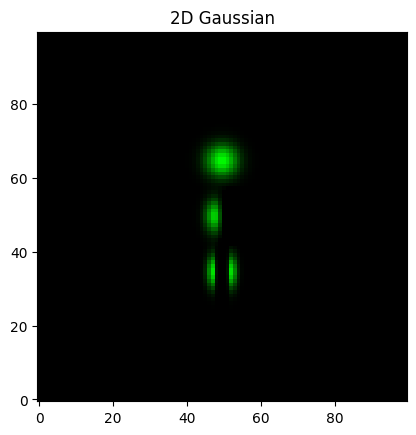

In [129]:
# w = torch.tensor([[-1,  -2, 1,  torch.pi/1.5, 0.5 - 2, 0.2 + 1], [-1,  -2, 1,  torch.pi/1.5, 0.5 - 2, 0.2 + 1]]).permute(1, 0)
w_prime = torch.tensor([[0, 0, 1,  -3, -3, -0.8,  0.45, 0.42], [1, 0, 0,  -2.5, -2.5, -0.8,  0.45, 0.42]]).permute(1, 0)

color_zeroth = torch.tensor([[0, 1, 0], [0, 0, 0], [0, 0, 0]]).permute(1, 0)
color_first = torch.tensor([[0, 0, 0], [0, 1, 0], [0, 0, 0]]).permute(1, 0)
color_second = torch.tensor([[0, 0, 0], [0, 0, 0], [0, 1, 0]]).permute(1, 0)
scale_shear = torch.tensor([[ -2.5, -2.5], [ -2.5, -2.5], [ -2.5, -2.5]]).permute(1, 0)
rotation = torch.tensor([0, 0, 0])
translation = torch.tensor([[0, 0.3], [0, 0], [0, -0.3]]).permute(1, 0)

plt.title("2D Gaussian")
plt.imshow(f_hat(color_zeroth, color_first, color_second, scale_shear, rotation, translation, 100, 100).permute(1, 2, 0), origin='lower', vmin=0, vmax=1)
plt.show()

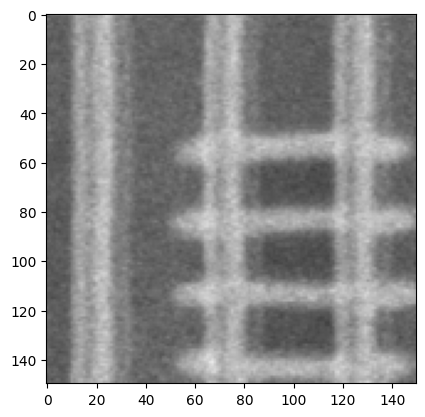

In [16]:
img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/sem-railroad.png').float(), 0, 0, 450, 450)

plt.imshow(torchvision.transforms.Resize(150)(img).permute(1, 2, 0) / 255, origin='upper')

In [19]:
learning_rate = 0.01
iterations = 4000
guassians = 1000

output_z = torchvision.transforms.Resize(50)(img).to(device) / 255.0
loss, w = train(learning_rate, iterations, guassians, output_z, False)

print(loss)

Iteration 400/4000
Loss: 0.01493
Iteration 800/4000
Loss: 0.00996
Iteration 1200/4000
Loss: 0.00812
Iteration 1600/4000
Loss: 0.00762
Iteration 2000/4000
Loss: 0.00652
Iteration 2400/4000
Loss: 0.00554
Iteration 2800/4000
Loss: 0.00482
Iteration 3200/4000
Loss: 0.00393
Iteration 3600/4000
Loss: 0.00316
Iteration 4000/4000
Loss: 0.00258
tensor(0.0026, device='cuda:0', grad_fn=<AddBackward0>)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.29344738..2.073354].


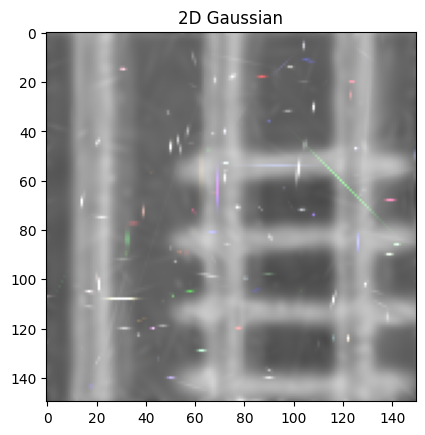

In [20]:
plot_image(w, 150, False)

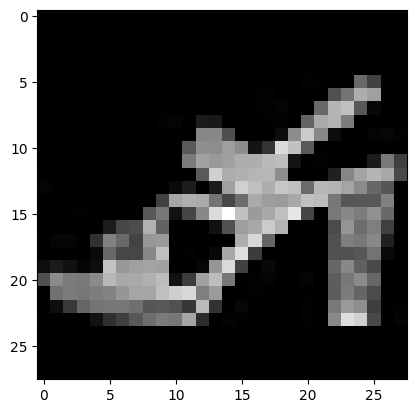

In [164]:
img = torchvision.io.decode_image('./data/fashionmnist-val-1003.png')[0]

plt.imshow(img, origin='upper', cmap='gray', vmin=0, vmax=255)
plt.show()

In [165]:

print(img.size())

learning_rate = 1e-3
iterations = 10000
guassians = 100
# create a 5x5 with a black stripe in the middle
output_z = img.to(device) / 255.0

loss, w = train(learning_rate, iterations, guassians, output_z, False)

print(loss)

torch.Size([28, 28])
Iteration 1000/10000
Loss: 0.07894
Iteration 2000/10000
Loss: 0.06571
Iteration 3000/10000
Loss: 0.06135
Iteration 4000/10000
Loss: 0.05803
Iteration 5000/10000
Loss: 0.05400
Iteration 6000/10000
Loss: 0.04942
Iteration 7000/10000
Loss: 0.04613
Iteration 8000/10000
Loss: 0.04224
Iteration 9000/10000
Loss: 0.03532
Iteration 10000/10000
Loss: 0.03356
tensor(0.0332, device='cuda:0', grad_fn=<MeanBackward0>)


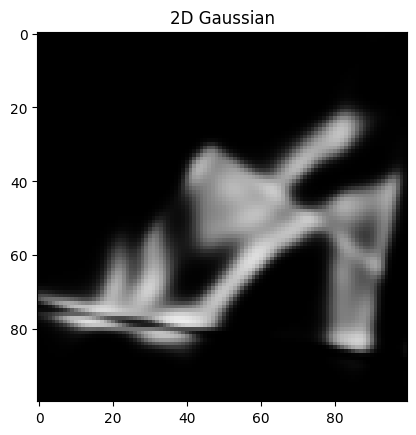

In [166]:

plot_image(w, 100, False)

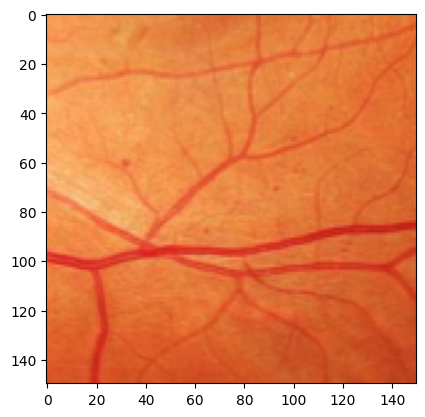

In [26]:
img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/retinal-vessels.jpg'), 0, 0, 230, 230).float()
img = torchvision.transforms.Resize(150)(img).permute(1, 2, 0) / 255

plt.imshow(img, origin='upper')

In [ ]:
img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/retinal-vessels.jpg'), 0, 0, 230, 230).float()

learning_rate = 0.01
iterations = 500
guassians = 2000

# create a 5x5 with a black stripe in the middle
output_z = torchvision.transforms.Resize(100)(img).to(device) / 255.0
print(output_z.size())

torch.Size([3, 100, 100])


In [22]:
loss, color_zeroth, color_first, color_second, scale_shear, rotation, translation = train(learning_rate, iterations, guassians, output_z, True)

/tmp/ipykernel_9925/3646408779.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scale_shear = torch.tensor(torch.randn(2, guassians, device=device) - 4)
/tmp/ipykernel_9925/3646408779.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  rotation = torch.tensor((torch.rand(guassians, device=device) - 0.5) * math.pi * 2, requires_grad=True)


Iteration 100/1000
Loss: 0.17457
Iteration 200/1000
Loss: 0.13417
Iteration 300/1000
Loss: 0.12497
Iteration 400/1000
Loss: 0.12036
Iteration 500/1000
Loss: 0.11609
Iteration 600/1000
Loss: 0.11464
Iteration 700/1000
Loss: 0.11174
Iteration 800/1000
Loss: 0.11078
Iteration 900/1000
Loss: 0.10747
Iteration 1000/1000
Loss: 0.10551


tensor(0.1061, device='cuda:0', grad_fn=<AddBackward0>)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.771533..1.6822212].


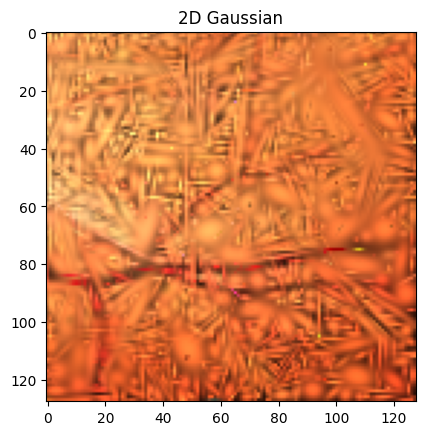

In [23]:
print(loss)
mask = color_zeroth.abs().mean(0) < 0.1
plot_image((color_zeroth), torch.zeros_like(color_first), torch.zeros_like(color_second), scale_shear, rotation, translation, 128)

tensor(0.1227, device='cuda:0', grad_fn=<AddBackward0>)
36


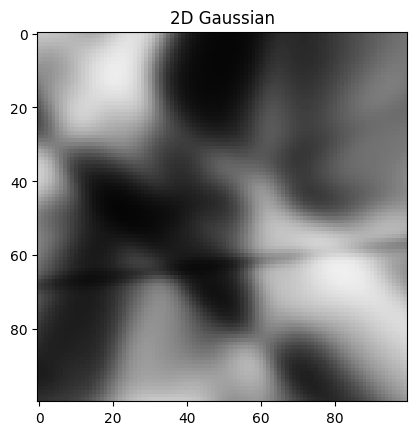

In [350]:
print(loss)
# find all w where |alpha| < 0.05 and |x1| > 1.5 and |x2| > 1.5
mask = (w[1]-w[2]).abs() > 3
# print(w[0][mask])
print(len(w[0][mask]))

plot_image(w[:, mask], 100, False)

torch.Size([3, 230, 230])
tensor(0.6579, device='cuda:0', grad_fn=<AddBackward0>)


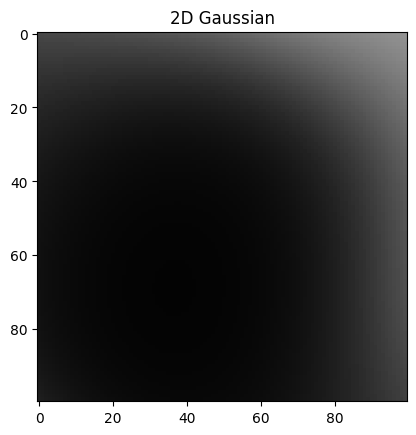

In [194]:
img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/retinal-vessels.jpg'), 0, 0, 230, 230).float()

print(img.size())

learning_rate = 1e-3
iterations = 0
guassians = 500


# create a 5x5 with a black stripe in the middle
output_z = torchvision.transforms.Resize(75)(img).mean(0).to(device) / 255.0
loss, w = train(learning_rate, iterations, guassians, output_z, False)

print(loss)

plot_image(w, 100, False)

In [60]:
img = torchvision.io.decode_image('./data/bsd300-castle.jpg')

print(img.size())

torch.Size([3, 481, 321])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07856125..1.0000002].


torch.Size([3, 100, 100])


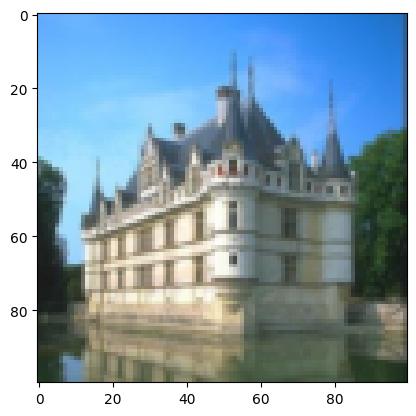

In [20]:
img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/bsd300-castle.jpg'), 0, 0, 321, 321).float()

learning_rate = 0.01
iterations = 500
guassians = 2000

# create a 5x5 with a black stripe in the middle
output_z = torchvision.transforms.Resize(100)(img).to(device) / 255.0
plt.imshow(output_z.cpu().permute(1, 2, 0), origin='upper', vmin=0, vmax=1)

print(output_z.size())

In [21]:
loss, color_zeroth, color_first, color_second, scale_shear, rotation, translation = train(learning_rate, iterations, guassians, output_z, True)

print(loss)

/tmp/ipykernel_7876/1003255215.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scale_shear = torch.tensor(torch.randn(2, guassians, device=device) - 4).requires_grad_(True)
/tmp/ipykernel_7876/1003255215.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  rotation = torch.tensor((torch.rand(guassians, device=device) - 0.5) * math.pi * 2, requires_grad=True)


Iteration 50/500
Loss: 0.15823
Iteration 100/500
Loss: 0.08005
Iteration 150/500
Loss: 0.04817
Iteration 200/500
Loss: 0.03612
Iteration 250/500
Loss: 0.02990
Iteration 300/500
Loss: 0.02553
Iteration 350/500
Loss: 0.02302
Iteration 400/500
Loss: 0.01955
Iteration 450/500
Loss: 0.01735
Iteration 500/500
Loss: 0.01589
tensor(0.0159, device='cuda:0', grad_fn=<AddBackward0>)


tensor(0.0159, device='cuda:0', grad_fn=<AddBackward0>)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1053777..0.47300336].


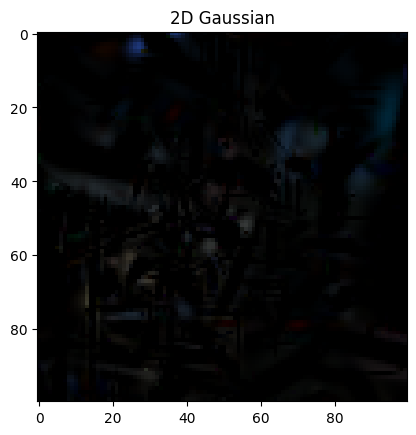

In [ ]:
print(loss)
mask = color_zeroth.abs().mean(0) < 0.1
plot_image((color_zeroth), (color_first), (color_second), scale_shear, rotation, translation, 100)

torch.Size([3, 321, 321])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.12591735..1.0000004].


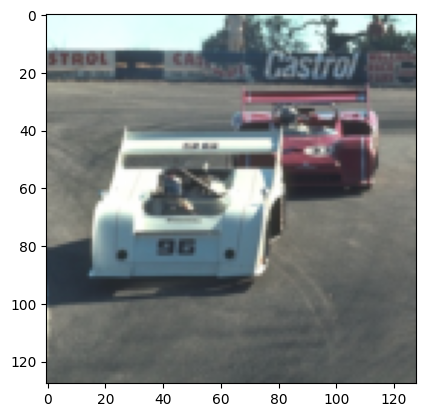

In [7]:

img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/bsd68-0005.png'), 0, 440-321, 321, 321).float()

print(img.size())

learning_rate = 0.01
iterations = 1000
guassians = 3000

# create a 5x5 with a black stripe in the middle
output_z = torchvision.transforms.Resize(128)(img).to(device) / 255.0
plt.imshow(output_z.cpu().permute(1, 2, 0), origin='upper', vmin=0, vmax=1)



In [8]:
loss, color_zeroth, color_first, color_second, scale_shear, rotation, translation = train(learning_rate, iterations, guassians, output_z, True)

print(loss)

/tmp/ipykernel_169063/3800837390.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scale_shear = torch.tensor(torch.randn(2, guassians, device=device) - 4)
/tmp/ipykernel_169063/3800837390.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  rotation = torch.tensor((torch.rand(guassians, device=device) - 0.5) * math.pi * 2, requires_grad=True)
/var/home/victor/Code/bep/.venv/lib64/python3.13/site-packages/torch/nn/functional.py:5163: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


Iteration 100/1000
Loss: 0.13320
Iteration 200/1000
Loss: 0.08347
Iteration 300/1000
Loss: 0.06527
Iteration 400/1000
Loss: 0.05595
Iteration 500/1000
Loss: 0.04886
Iteration 600/1000
Loss: 0.04328
Iteration 700/1000
Loss: 0.03862
Iteration 800/1000
Loss: 0.03466
Iteration 900/1000
Loss: 0.03141
Iteration 1000/1000
Loss: 0.02893
tensor(0.0290, device='cuda:0', grad_fn=<AddBackward0>)


In [23]:
print(loss)
mask = color_zeroth.abs().mean(0) < 0.1
print(mask.sum())

plot_image(color_zeroth[:, mask], color_first[:, mask], color_second[:, mask], scale_shear[:, mask], rotation[:, mask], translation[:, mask], 128)

tensor(0.0290, device='cuda:0', grad_fn=<AddBackward0>)
tensor(252, device='cuda:0')


IndexError: too many indices for tensor of dimension 1